In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [10]:
# ==========================================
# Task 6: Customer Segmentation
# Dataset: Mall Customer Dataset
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:

# ------------------------------------------
# Display Available Files
# ------------------------------------------

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/simtoor/mall-customers/Mall Customers.xlsx


In [4]:
# ------------------------------------------
# Load Dataset
# ------------------------------------------

import pandas as pd

df = pd.read_excel(
    '/kaggle/input/datasets/simtoor/mall-customers/Mall Customers.xlsx'
)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (200, 7)

First 5 Rows:
   CustomerID Gender  Age   Education  Marital Status  Annual Income (k$)  \
0           1      M   19  High School        Married                  15   
1           2      M   21     Graduate         Single                  15   
2           3      F   20     Graduate        Married                  16   
3           4      F   23  High School        Unknown                  16   
4           5      F   31   Uneducated        Married                  17   

   Spending Score (1-100)  
0                      39  
1                      81  
2                       6  
3                      77  
4                      40  


In [5]:

# ------------------------------------------
# Dataset Information
# ------------------------------------------

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB
None

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [6]:

# ------------------------------------------
# Summary Statistics
# ------------------------------------------

print("\nSummary Statistics:")
print(df.describe())



Summary Statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [8]:
print(df.columns.tolist())

['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status', 'Annual Income (k$)', 'Spending Score (1-100)']


In [12]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df['Education '] = le.fit_transform(df['Education '])

df['Marital Status'] = le.fit_transform(df['Marital Status'])

df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,1,19,3,1,15,39
1,2,1,21,2,2,15,81
2,3,0,20,2,1,16,6
3,4,0,23,3,3,16,77
4,5,0,31,5,1,17,40


In [13]:

# ==========================================
# Feature Selection
# ==========================================

# Using Income and Spending Score
# for Customer Segmentation

X = df[
    [
        'Age',
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
]

In [14]:


# ------------------------------------------
# Feature Scaling
# ------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

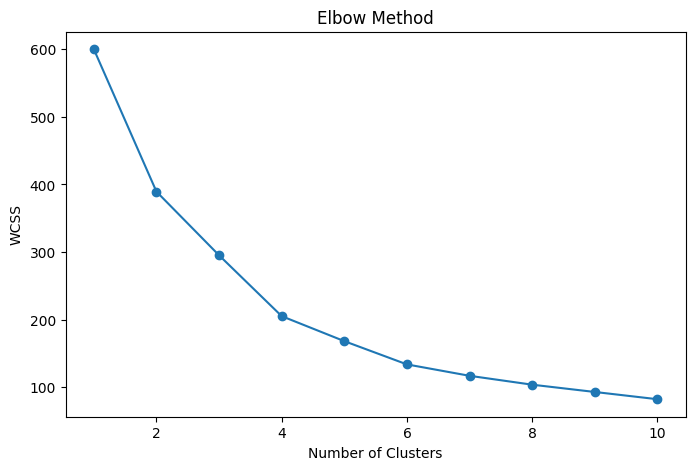

In [15]:


# ==========================================
# Find Optimal Number of Clusters
# Elbow Method
# ==========================================

wcss = []

for i in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()


In [16]:

# ==========================================
# Apply K-Means Clustering
# ==========================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Add Cluster Labels

df['Cluster'] = clusters

In [17]:


# ==========================================
# Silhouette Score
# ==========================================

score = silhouette_score(
    X_scaled,
    clusters
)

print("\nSilhouette Score:", round(score, 3))



Silhouette Score: 0.417


In [18]:
cluster_summary = df.groupby('Cluster').agg({
    'Age':'mean',
    'Annual Income (k$)':'mean',
    'Spending Score (1-100)':'mean'
})

print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


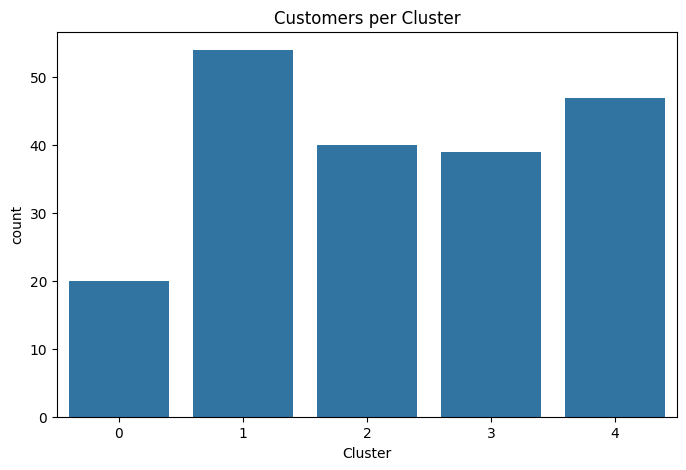

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Cluster',
    data=df
)

plt.title('Customers per Cluster')

plt.show()

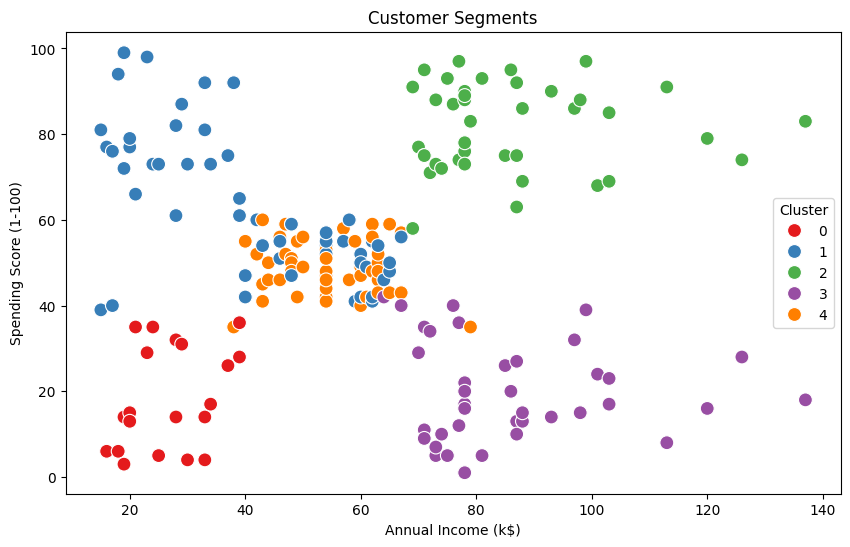

In [22]:

# ==========================================
# Cluster Visualization
# ==========================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title('Customer Segments')

plt.show()

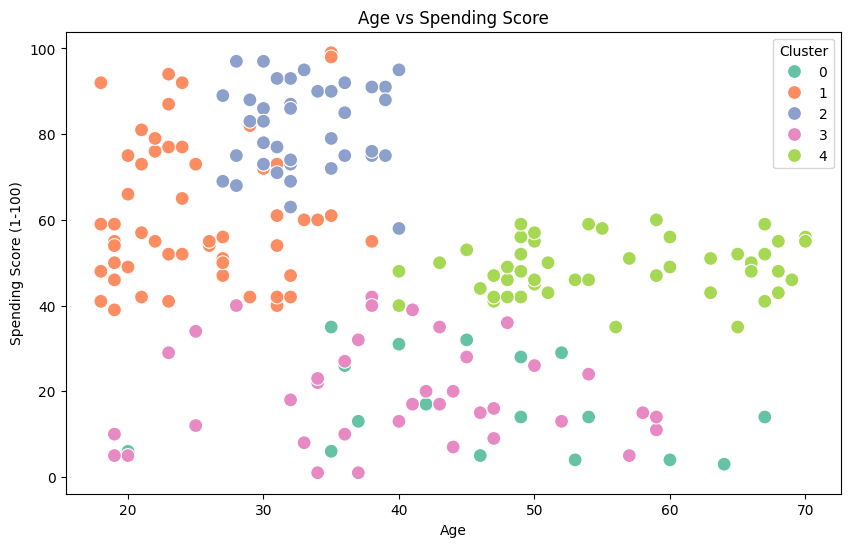

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    s=100
)

plt.title('Age vs Spending Score')

plt.show()

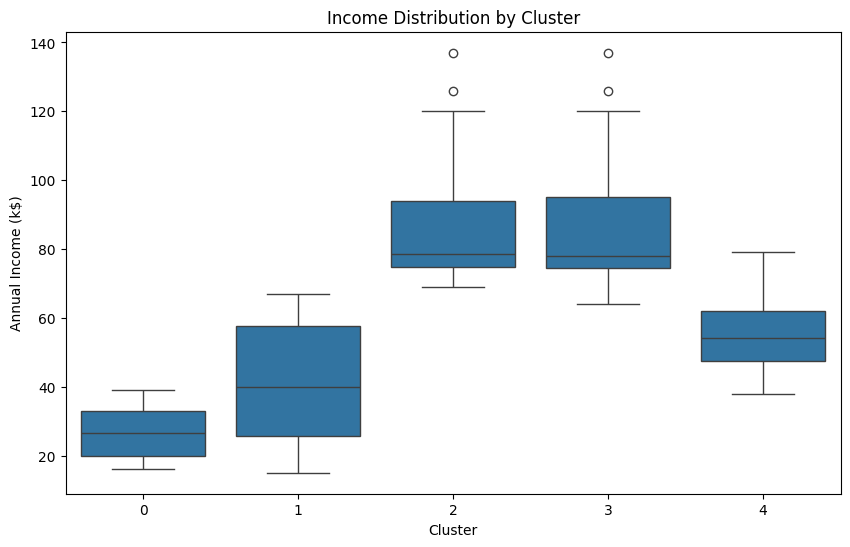

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Cluster',
    y='Annual Income (k$)',
    data=df
)

plt.title('Income Distribution by Cluster')

plt.show()

In [25]:
centroids = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroid_df = pd.DataFrame(
    centroids,
    columns=[
        'Age',
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
)

print("\nCluster Centroids:")
print(centroid_df)


Cluster Centroids:
         Age  Annual Income (k$)  Spending Score (1-100)
0  46.250000           26.750000               18.350000
1  25.185185           41.092593               62.240741
2  32.875000           86.100000               81.525000
3  39.871795           86.102564               19.358974
4  55.638298           54.382979               48.851064


In [26]:
print("="*60)
print("CUSTOMER SEGMENTATION REPORT")
print("="*60)

print("\nTotal Customers:", len(df))

print("\nCustomers Per Cluster:")
print(df['Cluster'].value_counts())

print("""
Insights:

Cluster 0:
High income and high spending customers.
Premium customers.

Cluster 1:
High income but lower spending.
Potential marketing targets.

Cluster 2:
Average income and spending.
Regular customers.

Cluster 3:
Low income and low spending.
Budget-conscious customers.

Cluster 4:
Young customers with high spending.
Ideal for promotional campaigns.

Business Recommendations:

1. Reward premium customers with loyalty programs.

2. Target high-income low-spending customers
   with personalized offers.

3. Design special campaigns for young shoppers.

4. Use cluster-based marketing instead of
   one-size-fits-all promotions.

5. Improve customer retention using
   personalized recommendations.
""")

CUSTOMER SEGMENTATION REPORT

Total Customers: 200

Customers Per Cluster:
Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64

Insights:

Cluster 0:
High income and high spending customers.
Premium customers.

Cluster 1:
High income but lower spending.
Potential marketing targets.

Cluster 2:
Average income and spending.
Regular customers.

Cluster 3:
Low income and low spending.
Budget-conscious customers.

Cluster 4:
Young customers with high spending.
Ideal for promotional campaigns.

Business Recommendations:

1. Reward premium customers with loyalty programs.

2. Target high-income low-spending customers
   with personalized offers.

3. Design special campaigns for young shoppers.

4. Use cluster-based marketing instead of
   one-size-fits-all promotions.

5. Improve customer retention using
   personalized recommendations.

